In [1]:
from orbitx import Orbit, Matchups
import datetime
import numpy as np

KeyboardInterrupt: 

C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py:141: UserWarning: The oldest TLE file is more recent than the start time requested.
 Oldest TLE file: 2020-11-21 19:06:03.724416
 Start time requested: 2020-02-01 00:00:00
  warnings.warn(


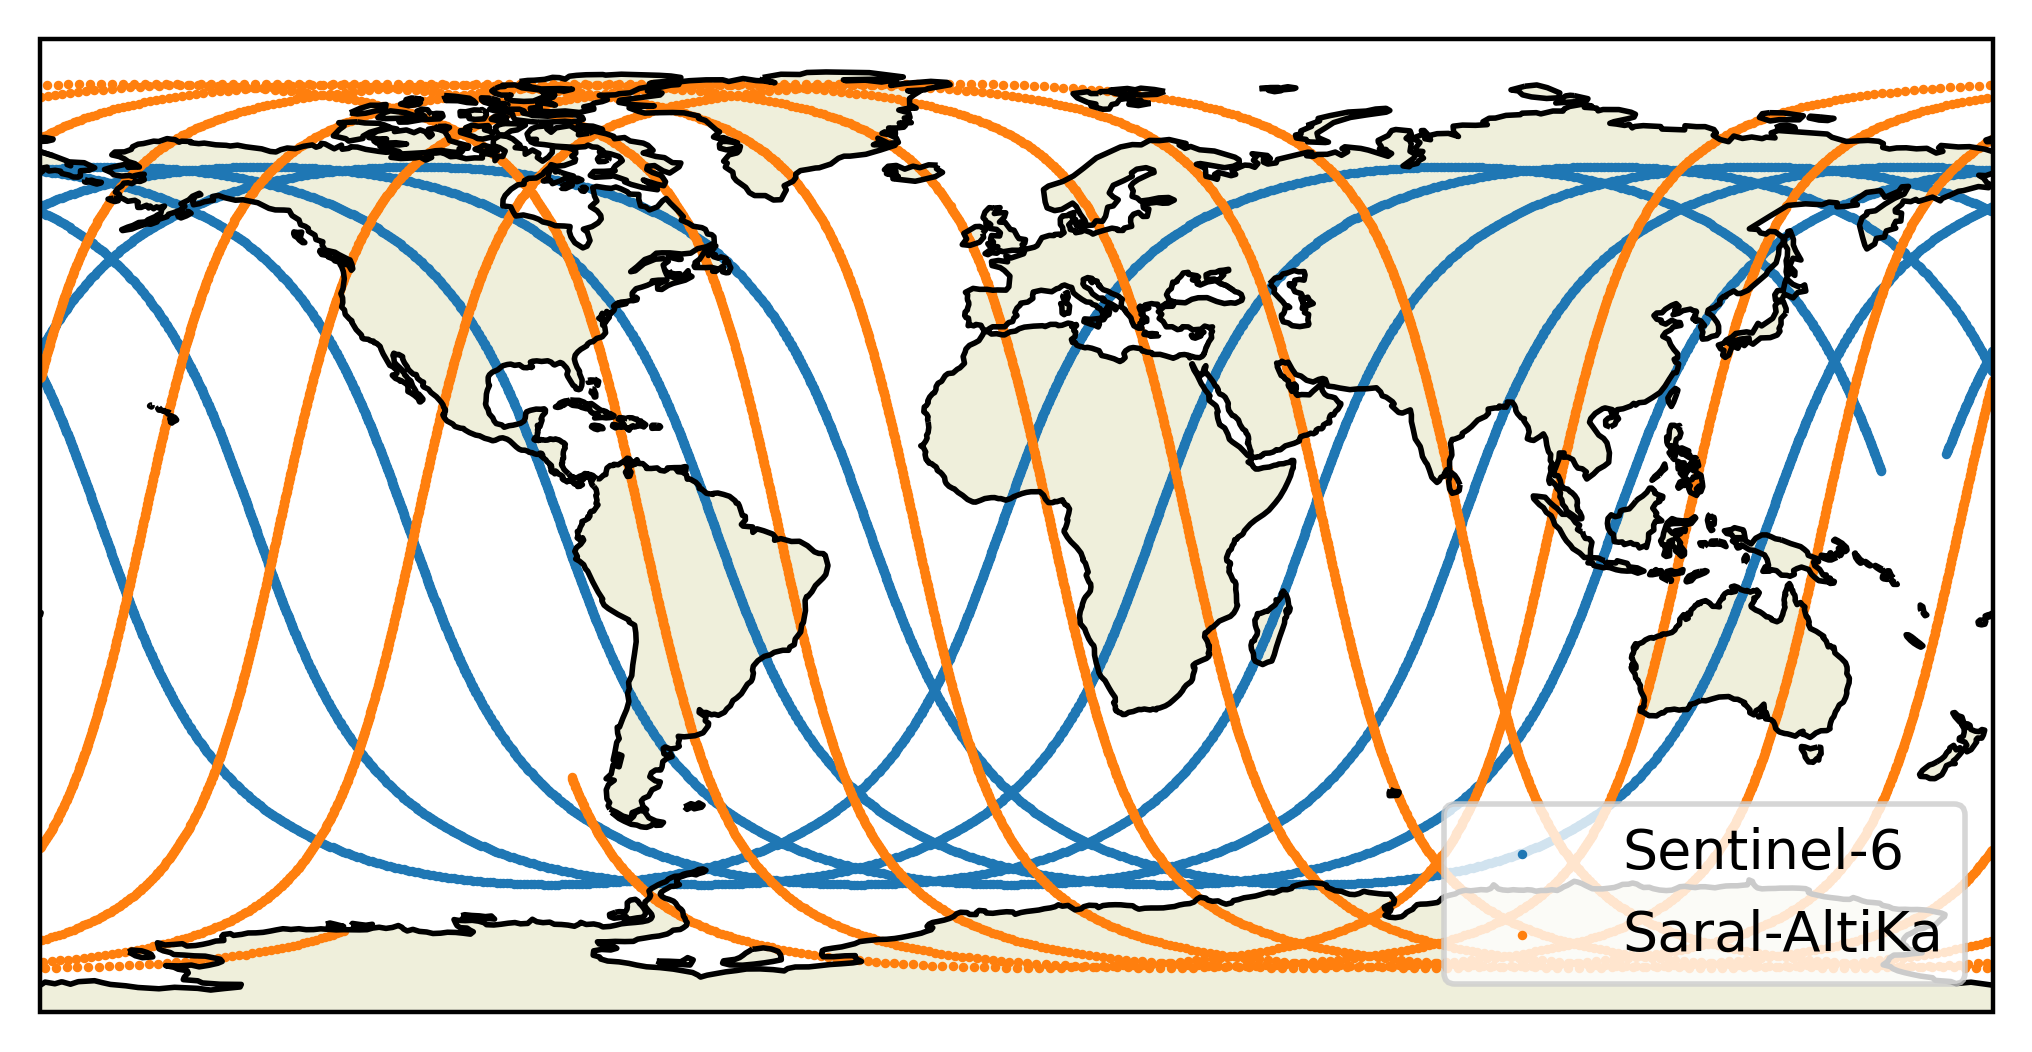

: 

In [ ]:
orbit = Orbit.simulate(
    satellites=["S6", "SA"],
    start_date=datetime.datetime(2020, 2, 1, 0, 0, 0),
    end_date=datetime.datetime(2020, 2, 1, 12, 0, 0),
    propagation_sampling_interval=20,
    interpolation_sampling_interval=5,
    reference_date=datetime.datetime(2000, 1, 1, 0, 0, 0)
)

plots = orbit.plot()

In [3]:
print(orbit)


Orbit object for satellites ['S6', 'SA'].
Start date: 2020-02-01 00:00:00
End date: 2020-02-01 12:00:00
Propagation sampling interval: 20
Interpolation sampling interval: 5
Reference date used to represent time in seconds since: 2000-01-01 00:00:00
Number of simulated times: 8641


In [4]:
print(orbit.orbits)

{'S6': {'lat': array([13.24776186, 13.49308294, 13.73840403, ..., 10.51522191,
       10.2703715 , 10.02552109], shape=(8641,)), 'lon': array([171.45210766, 171.54662824, 171.64114882, ..., 159.28087696,
       159.37214082, 159.46340468], shape=(8641,)), 'time': array([6.33830400e+08, 6.33830405e+08, 6.33830410e+08, ...,
       6.33873590e+08, 6.33873595e+08, 6.33873600e+08], shape=(8641,)), 'time_datetime': array([datetime.datetime(2020, 2, 1, 0, 0),
       datetime.datetime(2020, 2, 1, 0, 0, 5),
       datetime.datetime(2020, 2, 1, 0, 0, 10), ...,
       datetime.datetime(2020, 2, 1, 11, 59, 50),
       datetime.datetime(2020, 2, 1, 11, 59, 55),
       datetime.datetime(2020, 2, 1, 12, 0)], shape=(8641,), dtype=object)}, 'SA': {'lat': array([-74.64432136, -74.886214  , -75.12810664, ..., -46.94829116,
       -46.65778652, -46.36728189], shape=(8641,)), 'lon': array([-123.95466913, -124.64000603, -125.32534293, ...,  -81.76234795,
        -81.87751761,  -81.99268728], shape=(8641,)),

In [5]:
orbit.to_netcdf("./test_export/")

In [1]:
from orbitx import Matchups
import datetime
import numpy as np
matchups = Matchups.find_matchups(
    satellites=["CS2", "J3"],
    start_date=datetime.datetime(2012, 1, 1, 0, 0, 0),
    end_date=datetime.datetime(2012, 1, 1, 12, 0, 0),
    propagation_sampling_interval = 60,
    interpolation_sampling_interval = 5,
    space_diff_threshold = 290,
    time_diff_threshold = 900,
    check_before = True,
    check_after = True,
    has_land_ocean_mask = True,
    reference_date=datetime.datetime(2000, 1, 1, 0, 0, 0)
)

C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py:141: UserWarning: The oldest TLE file is more recent than the start time requested.
 Oldest TLE file: 2016-01-17 20:22:02.081280
 Start time requested: 2011-12-31 23:45:00
  warnings.warn(


In [2]:
print(matchups)


Matchup object with following attributes:
Satellites considered: ['CS2', 'J3']
Date from which matchups are looked for: 2012-01-01 00:00:00
Date until which matchups are looked for: 2012-01-01 12:00:00
Maximum time difference between members of a matchup: 900 (seconds)
Maximum distance between members of a matchup: 290
Are matchups in which on of the satellites appears before the start date considered? True
Are matchups in which on of the satellites appears after the end date considered? True
Has this matchup a land/ocean mask? True
Number of matchups found: 53



In [4]:
print(matchups.matchups.attrs.keys())

dict_keys(['satellites', 'start_date', 'end_date', 'time_diff_threshold', 'space_diff_threshold', 'check_before', 'check_after', 'has_land_ocean_mask', 'interpolation_sampling_interval', 'propagation_sample_interval', 'sat1', 'sat2'])


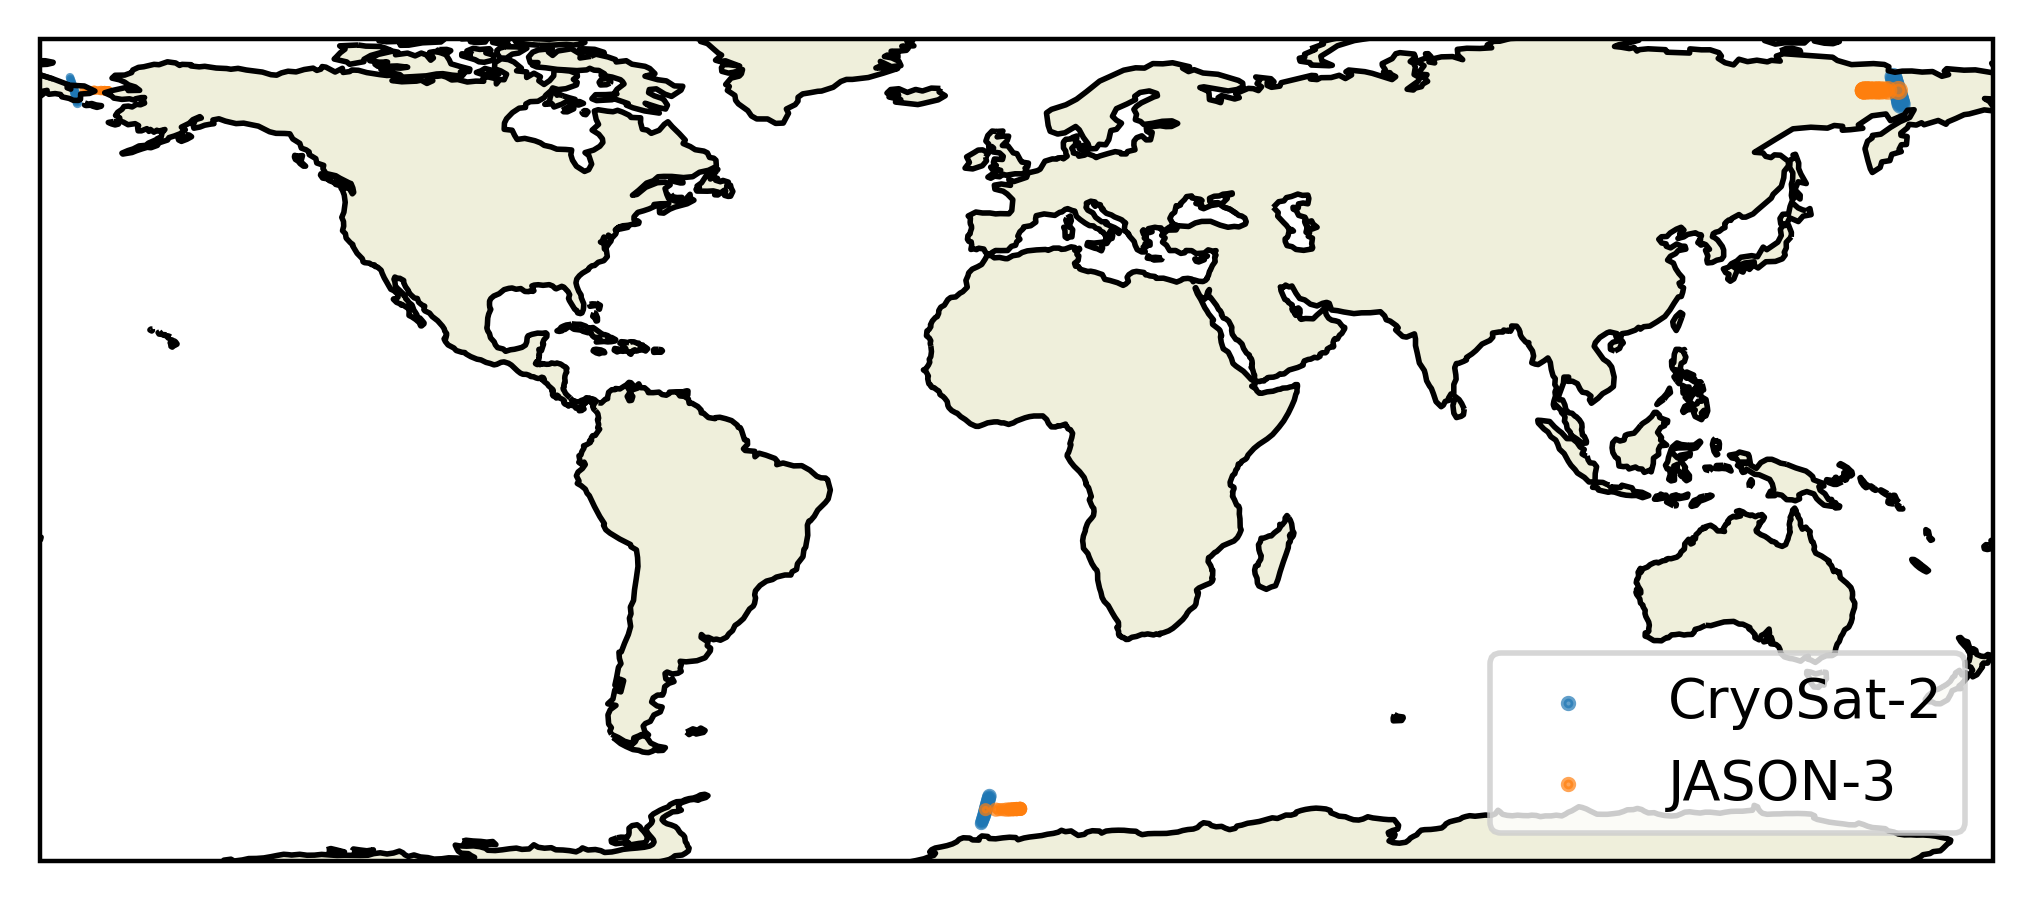

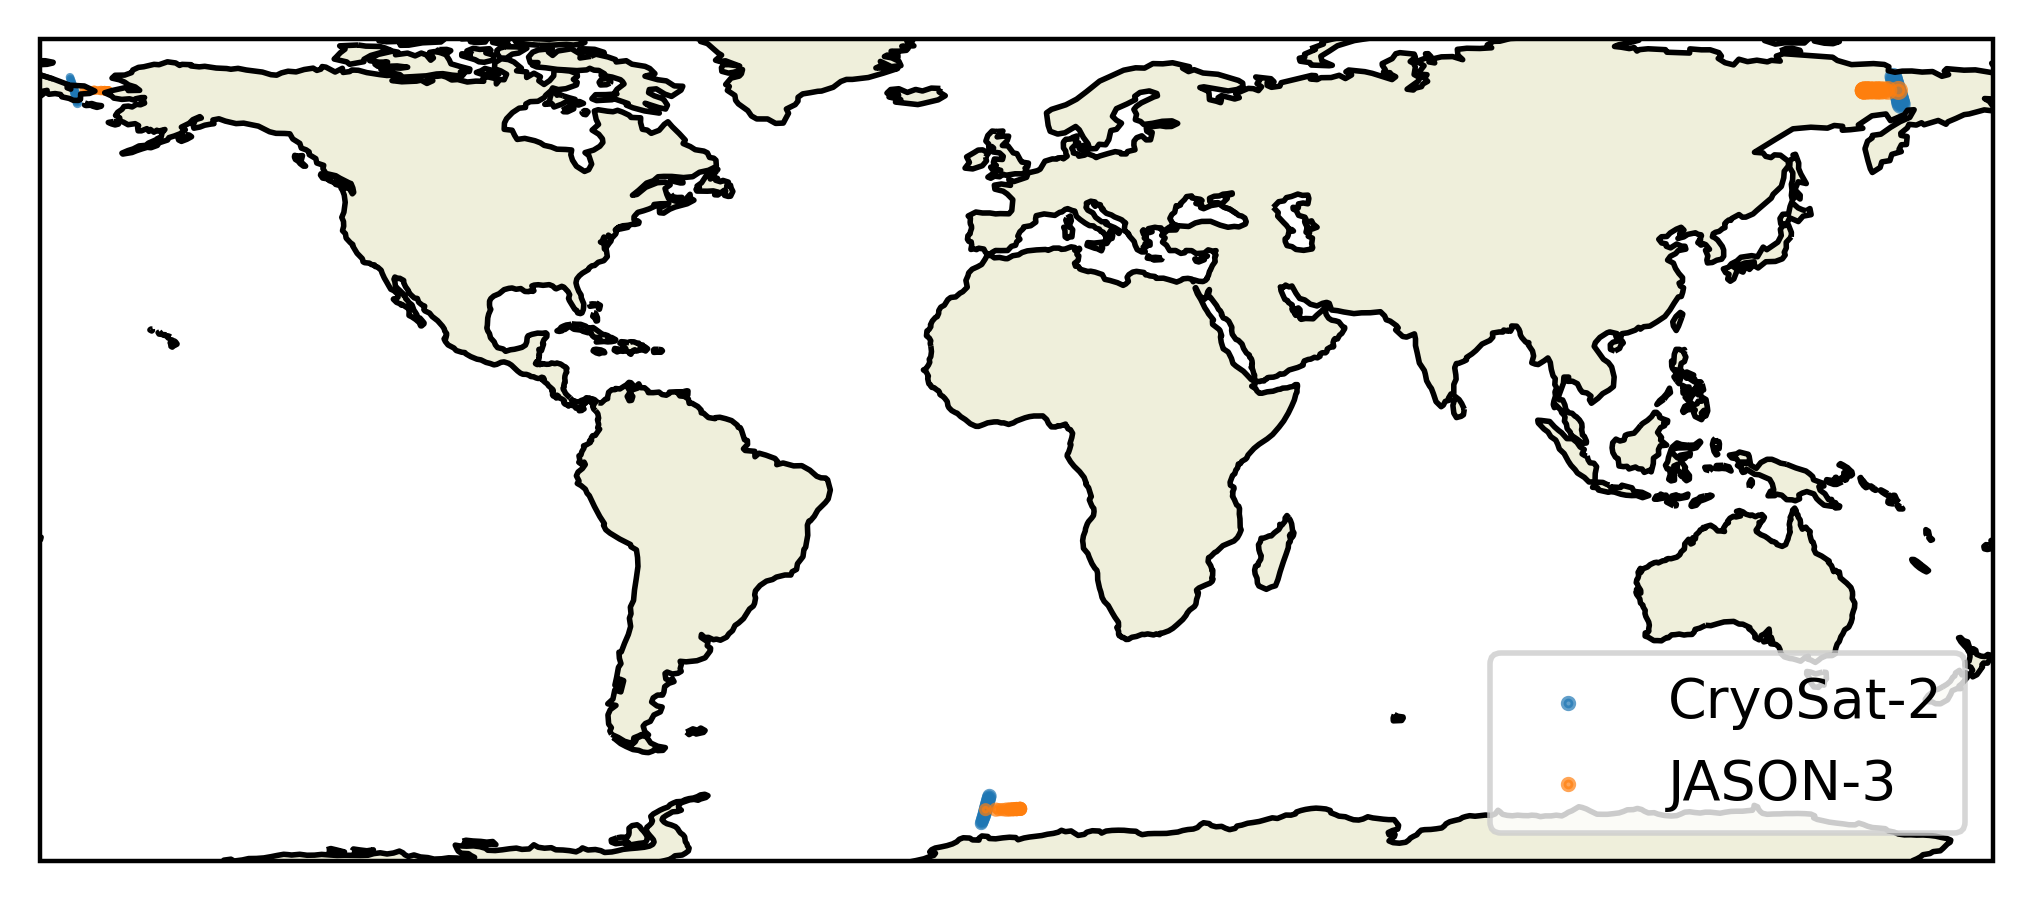

In [2]:
matchups.plot()

In [7]:
print(matchups.matchups)

<xarray.Dataset> Size: 5kB
Dimensions:         (time: 53)
Coordinates:
  * time            (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
Data variables:
    lat1            (time) float64 424B 63.72 64.02 64.32 ... 68.01 68.31 68.61
    lon1            (time) float64 424B -173.1 -173.2 -173.3 ... 160.7 160.7
    lat2            (time) float64 424B 66.12 66.13 66.08 ... 66.11 66.1 66.1
    lon2            (time) float64 424B -171.3 -170.0 -168.8 ... 157.8 159.0
    distance        (time) float64 424B 279.3 276.7 285.8 ... 283.6 277.1 287.5
    time_datetime   (time) datetime64[ns] 424B 2012-01-01T09:54:25 ... 2012-0...
    time2           (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
    time_datetime2  (time) datetime64[ns] 424B 2012-01-01T09:44:50 ... 2012-0...
    delay           (time) float64 424B 575.0 570.0 565.0 ... -75.0 -80.0 -85.0
    land_mask_1     (time) <U1 212B 'O' 'O' 'O' 'O' 'O' ... 'O' 'O' 'O' 'O' 'O'
    land_mask_2     (time) <U1 212B 'O' 'O' 'O' 'O'

In [2]:
matchups.to_netcdf("./test_export/")

In [ ]:
loaded_matchup = Matchups.from_netcdf("./test_export/20120101_20120101_psi60_isi5_matchups_CS2_J3_c2c290_tdt900.nc")